# N2 vs N3 Infraslow Analysis Demo

Downstream analysis/visualization notebook over `infraslow.pipeline`'s already-computed
per-subject ISFS spectrum and phase features (see `src/scripts/preprocessing.py` for how
the underlying `.npz`/`.csv` artifacts under `/scratch/users/chaisaen/usleep_dryrun_v2/data/`
were generated). No EEG filtering, spindle/slow-wave detection, or envelope computation
happens here -- every number below comes from `infraslow.pipeline.pipeline.run_subject_state_channel`
and `infraslow.stat.state_comparison`, reused unmodified from the rest of the project.

Compares **N2 vs N3** on channel **C3** across every eligible subject (sorted by id) with
usable spindle-containing bouts in both states, or the first `N_SUBJECTS` if that's set to
a number instead of `None`.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infraslow.pipeline import pipeline as ppl
from infraslow.pipeline import phase as pph
from infraslow.processing.infraslow import (
    DEFAULT_INFRASLOW_BAND,
    DEFAULT_BASELINE_BAND,
    bigaussian,
    fit_isfs,
)
from infraslow.stat import state_comparison as stc

# infraslow.pipeline.pipeline transitively imports infraslow.pipeline.figures, which
# calls matplotlib.use("Agg") at import time (a headless-safe default for the batch
# pipeline) -- that forces a non-interactive backend, silently overriding an earlier
# `%matplotlib inline`. Issuing the magic here, after those imports, re-enables inline
# figure display in this notebook without touching the pre-existing pipeline module.
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
ORANGE, LORANGE = '#d2691e', '#f2c14e'
COLORS = {"N2": (PURPLE, LPURPLE), "N3": (ORANGE, LORANGE)}

DATA_DIR = Path("/scratch/users/chaisaen/usleep_dryrun_v2/data")
CHANNEL = "C3"
STATES = ("N2", "N3")
# EVENT selects which artifact pathway drives run_subject_state_channel's ISFS
# spectrum + phase-locking analysis (see its docstring / _EVENT_SPECS in
# infraslow.pipeline.pipeline): "spindle" (default, this notebook) pairs sigma-band
# ISFS spectra with spindle_bouts.npz["spindle"]/spindle_yasa.csv["Peak"]; "sw" is the
# delta-band/slow-wave analog -- see demo_plot_and_compared_delta.ipynb.
EVENT = "spindle"
# DATA_DIR holds 169,740 subject directories -- None (scan/use everything) is not
# practical here (each candidate costs several file reads + a curve_fit; the full-cohort
# batch run took 8+ hours to process its first ~30 subjects). N_SUBJECTS caps how many
# *usable* subjects to keep; CANDIDATE_LIMIT (next cell) caps how many candidates get
# scanned to find them -- set N_SUBJECTS to an int for interactive/notebook use.
N_SUBJECTS = 2000


## 2. Find Eligible Subjects

Sorted by id (`infraslow.pipeline.io.discover_subjects`'s own order, preserved by
`find_paired_subject_data`). `find_paired_subject_data` guarantees a non-`None`
**spectrum** record for every state in `STATES` (pairing preserved by construction,
not filtered independently per state) -- but a non-`None` record is not the same as a
*usable* one. `infraslow.pipeline.spectrum`'s `_nan_spectrum_features` fallback can
return a non-`None` record whose spectrum fields (`peak_freq_hz`, `curves["rel"]`,
`curves["corrected"]`, etc.) are all NaN when zero ISFS rows match. Separately (and by
design, see its docstring), `infraslow.pipeline.phase.compute_subject_phase_features`
excludes a subject/state with fewer than `DEFAULT_ISFS_MIN_EVENTS` in-cycle spindle
events from phase reporting -- `phase_bin_rates=None` in that case -- independent of
whether its spectrum was computable. A subtler case: a subject/state can have >=5
*total* detected spindle events but zero *in-cycle* ISFS events, in which case
`phase_bin_rates` is `[0.0]*8` (NOT `None`) and `mean_phase` is NaN -- that would
silently pass a `phase_bin_rates is not None` check alone. Section 5 (phase analysis)
needs real, finite phase data on every selected subject/state, and Section 7's circular
supplement needs a finite `mean_phase` for every subject in both states to keep the N2/N3
pairing intact -- so we pull a candidate pool from `find_paired_subject_data` (see
`CANDIDATE_LIMIT` below) and filter down to every subject (still sorted by id, capped at
`N_SUBJECTS` if that's set) that has a finite spectrum AND non-degenerate, finite phase
data in every state.

In [2]:
def _is_usable(entry):
    # A non-None spectrum record from run_subject_state_channel is not sufficient on its
    # own: it can still return an all-NaN spectrum record (zero ISFS rows matched --
    # infraslow.pipeline.spectrum._nan_spectrum_features), or a record with all-zero
    # phase_bin_rates and NaN mean_phase (zero in-cycle-ISFS events despite >= 5 total
    # detected spindles -- phase_bin_rates is [0.0]*8, NOT None, in that case, so it
    # would silently pass a phase_bin_rates-is-not-None-only check). Require a finite
    # spectrum plus finite, non-degenerate phase data in every state.
    for state in STATES:
        record = entry[state][0]
        phase_bin_rates = record.get("phase_bin_rates")
        if phase_bin_rates is None:
            return False
        if not np.isfinite(record["peak_freq_hz"]):
            return False
        if sum(phase_bin_rates) <= 0:
            return False
        if not np.isfinite(record["mean_phase"]):
            return False
    return True


# CANDIDATE_LIMIT bounds how many subjects get scanned in total. When N_SUBJECTS is set,
# the loop below stops as soon as N_SUBJECTS *usable* subjects are found (not a fixed
# margin scanned up front) -- so CANDIDATE_LIMIT=None ("no cap") stays fast for a small
# N_SUBJECTS: it only scans as far into the (sorted-by-id, 169,740-subject) cohort as it
# actually needs to. CANDIDATE_LIMIT only matters as a safety cap when N_SUBJECTS is also
# None (nothing to stop early on -- that combination does mean "scan everything"), or if
# usable subjects turn out to be rarer than expected and you want to bound runtime anyway.
CANDIDATE_LIMIT = None
verbose = True  # print live scan progress (one line per subject scanned)

candidates = {}
n_usable = 0
n_scanned = 0
for subject_id in ppl.pio.discover_subjects(DATA_DIR):
    if CANDIDATE_LIMIT is not None and len(candidates) >= CANDIDATE_LIMIT:
        break
    n_scanned += 1
    per_state = {}
    for state in STATES:
        record, bout_records, _failure, curves = ppl.run_subject_state_channel(
            DATA_DIR, subject_id, CHANNEL, state, event=EVENT, return_curves=True,
        )
        if record is None:
            break
        per_state[state] = (record, bout_records, curves)
    if len(per_state) != len(STATES):
        if verbose:
            print(f"[{n_scanned}] {subject_id}: not paired (missing/failed a state) "
                  f"-- {len(candidates)} paired, {n_usable} usable so far")
        continue
    candidates[subject_id] = per_state
    usable = _is_usable(per_state)
    if usable:
        n_usable += 1
    if verbose:
        target = f"/{N_SUBJECTS}" if N_SUBJECTS is not None else ""
        print(f"[{n_scanned}] {subject_id}: paired, {'usable' if usable else 'not usable'} "
              f"-- {len(candidates)} paired, {n_usable}{target} usable so far")
    if usable and N_SUBJECTS is not None and n_usable >= N_SUBJECTS:
        break

phase_complete = {sid: data for sid, data in candidates.items() if _is_usable(data)}
# Slicing a list with [:None] returns the whole list, so this keeps every usable
# subject when N_SUBJECTS is None and caps at N_SUBJECTS (first N by id) otherwise.
paired_data = dict(list(phase_complete.items())[:N_SUBJECTS])
SUBJECT_IDS = list(paired_data)
# if N_SUBJECTS is not None:
#     assert len(SUBJECT_IDS) == N_SUBJECTS, (
#         f"expected {N_SUBJECTS} paired subjects with usable, finite spectrum AND phase data, "
#         f"found {len(SUBJECT_IDS)} among {len(candidates)} spectrum-paired candidates scanned "
#         f"(exhausted the cohort before finding enough -- try raising CANDIDATE_LIMIT if it "
#         f"wasn't already None, or there may not be enough usable subjects available)"
#     )

print(f"Selected {len(SUBJECT_IDS)} subjects with usable, finite {'/'.join(STATES)} spectrum + "
      f"phase data on {CHANNEL} (out of {len(candidates)} spectrum-paired candidates scanned):")
for sid in SUBJECT_IDS:
    print(f"  {sid}")

[1] 317497: not paired (missing/failed a state) -- 0 paired, 0 usable so far
[2] 317947: not paired (missing/failed a state) -- 0 paired, 0 usable so far
[3] 318517: not paired (missing/failed a state) -- 0 paired, 0 usable so far


[4] 318562: not paired (missing/failed a state) -- 0 paired, 0 usable so far
[5] 318619: not paired (missing/failed a state) -- 0 paired, 0 usable so far
[6] 318658: not paired (missing/failed a state) -- 0 paired, 0 usable so far


[7] 318661: not paired (missing/failed a state) -- 0 paired, 0 usable so far
[8] 318667: not paired (missing/failed a state) -- 0 paired, 0 usable so far


[9] 318668: paired, usable -- 1 paired, 1/2000 usable so far
[10] 318679: not paired (missing/failed a state) -- 1 paired, 1 usable so far
[11] 320749: not paired (missing/failed a state) -- 1 paired, 1 usable so far


[12] 320750: not paired (missing/failed a state) -- 1 paired, 1 usable so far
[13] 320753: not paired (missing/failed a state) -- 1 paired, 1 usable so far
[14] 320756: not paired (missing/failed a state) -- 1 paired, 1 usable so far
[15] 320757: not paired (missing/failed a state) -- 1 paired, 1 usable so far


...

[88] 333660: not paired (missing/failed a state) -- 9 paired, 2 usable so far


[89] 333665: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[90] 333667: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[91] 335556: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[92] 335558: not paired (missing/failed a state) -- 9 paired, 2 usable so far


[93] 335560: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[94] 335561: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[95] 335562: not paired (missing/failed a state) -- 9 paired, 2 usable so far
[96] 335563: not paired (missing/failed a state) -- 9 paired, 2 usable so far


[97] 335564: paired, not usable -- 10 paired, 2/2000 usable so far
[98] 335565: not paired (missing/failed a state) -- 10 paired, 2 usable so far
[99] 335566: paired, not usable -- 11 paired, 2/2000 usable so far


[100] 335567: not paired (missing/failed a state) -- 11 paired, 2 usable so far
Selected 2 subjects with usable, finite N2/N3 spectrum + phase data on C3 (out of 11 spectrum-paired candidates scanned):
  318668
  324389


## 3. Load Subject Data

`paired_data` (from Section 2) already holds every `(record, bout_records, curves)` this
notebook needs -- no further disk I/O happens below. This section validates the expected
keys/shapes are present and assembles the two tidy per-state feature tables
(`n2_df`/`n3_df`) the rest of the notebook uses.

In [3]:
REQUIRED_RECORD_KEYS = {
    "subject_id", "sleep_state", "peak_freq_hz", "peak_period_s", "bandwidth_hz", "auc",
    "chromatogram_peak_area", "bi_gaussian_amp", "bi_gaussian_mu", "bi_gaussian_sd_l",
    "bi_gaussian_sd_r", "phase_bin_rates", "mean_phase", "resultant_length",
}
for sid in SUBJECT_IDS:
    for state in STATES:
        record, _bout_records, curves = paired_data[sid][state]
        missing = REQUIRED_RECORD_KEYS - record.keys()
        assert not missing, f"{sid}/{state} missing keys: {missing}"
        assert curves["freqs"].shape == curves["rel"].shape == curves["corrected"].shape
        assert np.isfinite(curves["rel"]).all(), f"{sid}/{state}: non-finite curves['rel']"
        assert np.isfinite(curves["corrected"]).all(), f"{sid}/{state}: non-finite curves['corrected']"
        assert len(record["phase_bin_rates"]) == 8

n2_df = pd.DataFrame([paired_data[sid]["N2"][0] for sid in SUBJECT_IDS])
n3_df = pd.DataFrame([paired_data[sid]["N3"][0] for sid in SUBJECT_IDS])
print(f"n2_df: {n2_df.shape}, n3_df: {n3_df.shape}")
print("All subject/state records contain the expected ISFS spectrum and phase keys, "
      "and all curves are finite.")

n2_df: (2, 35), n3_df: (2, 35)
All subject/state records contain the expected ISFS spectrum and phase keys, and all curves are finite.


## 4. N2 vs N3 ISFS Spectral Analysis

### 4.1 Subject-Level Spectra

In [4]:
# The frequency grid is fixed by preprocessing.py's WINDOW_SEC (not per-bout length),
# so every subject/state shares the same `freqs` -- verify that before stacking.
freqs = paired_data[SUBJECT_IDS[0]]["N2"][2]["freqs"]
for sid in SUBJECT_IDS:
    for state in STATES:
        assert np.allclose(paired_data[sid][state][2]["freqs"], freqs)

rel_by_state = {
    state: np.stack([paired_data[sid][state][2]["rel"] for sid in SUBJECT_IDS])
    for state in STATES
}
corrected_by_state = {
    state: np.stack([paired_data[sid][state][2]["corrected"] for sid in SUBJECT_IDS])
    for state in STATES
}
band_m = (freqs >= DEFAULT_INFRASLOW_BAND[0]) & (freqs <= DEFAULT_INFRASLOW_BAND[1])
{state: rel_by_state[state].shape for state in STATES}

{'N2': (2, 40), 'N3': (2, 40)}

### 4.2 Average Relative Spectral Power

In [5]:
# Subject-level average (not pooled): mean +/- SEM across the 10 subjects' own
# per-subject relative-power curves -- infraslow.stat.state_comparison.mean_sem.
rel_mean = {state: stc.mean_sem(rel_by_state[state]) for state in STATES}

### 4.3 Baseline Correction

Baseline correction (subtracting the mean power over `DEFAULT_BASELINE_BAND`) was already
applied per-subject/state by `infraslow.pipeline.spectrum.compute_subject_spectrum_features`
(via `infraslow.processing.infraslow.baseline_correct`) when `find_paired_subject_data` built
`paired_data` in Section 2 -- `corrected_by_state` (below) is that result, not recomputed.

In [6]:
corrected_mean = {state: stc.mean_sem(corrected_by_state[state]) for state in STATES}

### 4.4 Bi-Gaussian Fits

Each subject's own bi-Gaussian fit parameters are already in `n2_df`/`n3_df`
(`bi_gaussian_*`, `peak_freq_hz`, `bandwidth_hz`, `auc`, `chromatogram_peak_area` -- see
Section 6/7). For the group-comparison figure below, `fit_isfs` (unmodified, the same
function `infraslow.pipeline.spectrum.compute_subject_spectrum_features` calls per subject)
is applied once more directly to each state's **group-average** baseline-corrected
spectrum, giving one representative bi-Gaussian curve per state to overlay.

In [7]:
group_fit = {}
for state in STATES:
    mean_corrected = corrected_mean[state][0]
    group_fit[state] = fit_isfs(
        freqs, mean_corrected, infraslow_band=DEFAULT_INFRASLOW_BAND, baseline_band=DEFAULT_BASELINE_BAND,
    )
    fit = group_fit[state]
    print(f"{state} group fit: peak={fit['mu']:.4f} Hz (~{1/fit['mu']:.0f} s) | "
          f"bandwidth={fit['bandwidth']:.4f} Hz | detected={fit['detected']}")

N2 group fit: peak=0.0200 Hz (~50 s) | bandwidth=0.0304 Hz | detected=True
N3 group fit: peak=0.0175 Hz (~57 s) | bandwidth=0.0138 Hz | detected=True


#### Figure: N2 vs N3 average ISFS spectrum

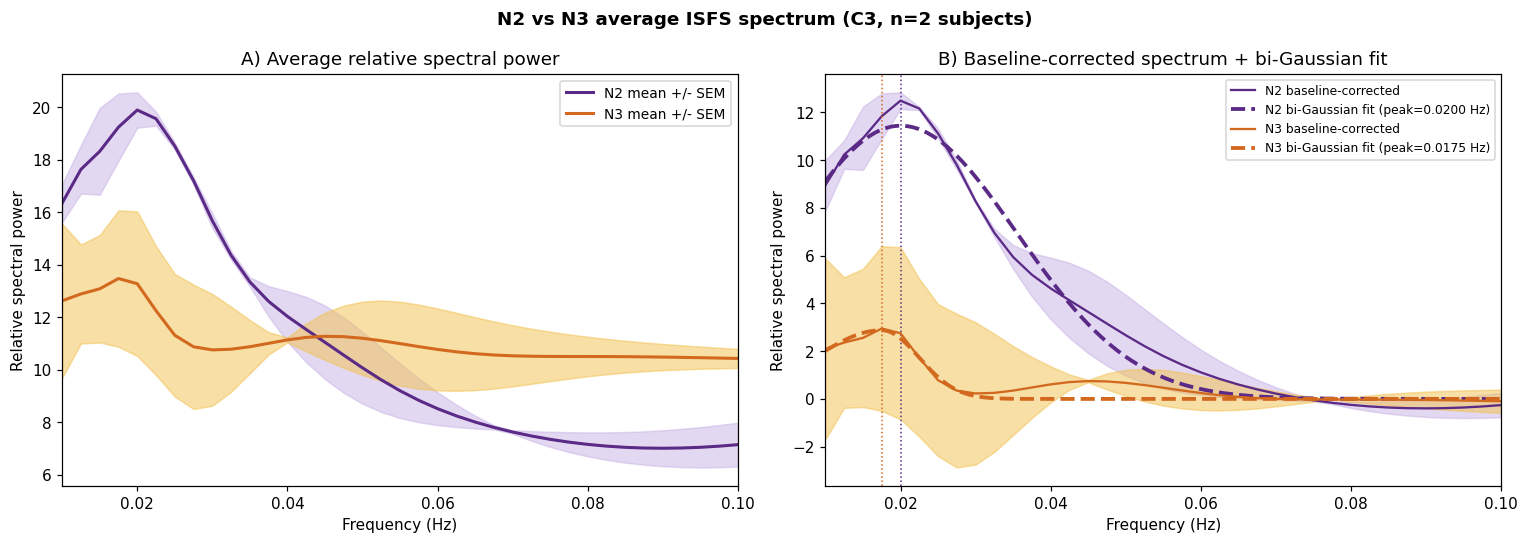

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

for state in STATES:
    dark, light = COLORS[state]
    mean_rel, sem_rel = rel_mean[state]
    axL.fill_between(freqs[band_m], (mean_rel - sem_rel)[band_m], (mean_rel + sem_rel)[band_m],
                      color=light, alpha=0.5)
    axL.plot(freqs[band_m], mean_rel[band_m], color=dark, lw=2, label=f"{state} mean +/- SEM")
axL.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="A) Average relative spectral power")
axL.legend(frameon=True, fontsize=9)

fg = np.linspace(*DEFAULT_INFRASLOW_BAND, 400)
for state in STATES:
    dark, light = COLORS[state]
    mean_corr, sem_corr = corrected_mean[state]
    fit = group_fit[state]
    axR.fill_between(freqs[band_m], (mean_corr - sem_corr)[band_m], (mean_corr + sem_corr)[band_m],
                      color=light, alpha=0.5)
    axR.plot(freqs[band_m], mean_corr[band_m], color=dark, lw=1.5, label=f"{state} baseline-corrected")
    axR.plot(fg, bigaussian(fg, *fit["popt"]), color=dark, lw=2.5, ls="--",
              label=f"{state} bi-Gaussian fit (peak={fit['mu']:.4f} Hz)")
    axR.axvline(fit["mu"], color=dark, lw=1, ls=":")
axR.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="B) Baseline-corrected spectrum + bi-Gaussian fit")
axR.legend(frameon=True, fontsize=8)

fig.suptitle(f"N2 vs N3 average ISFS spectrum ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)", fontweight="bold")
fig.tight_layout()

## 5. N2 vs N3 Spindle Phase Analysis

### 5.1 Subject-Level Phase Distributions

Each subject/state's 8-bin `phase_bin_rates` (already computed by
`infraslow.pipeline.phase.compute_subject_phase_features` inside `find_paired_subject_data`,
Section 2) is stacked into `(n_subjects, 8)` arrays; `bin_center_angle` (unmodified, from
`infraslow.pipeline.phase`) gives each bin's phase angle for the x-axis below.

In [9]:
phase_rates = {
    state: np.stack([paired_data[sid][state][0]["phase_bin_rates"] for sid in SUBJECT_IDS])
    for state in STATES
}
bin_centers = pph.bin_center_angle(np.arange(1, 9))
{state: phase_rates[state].shape for state in STATES}

{'N2': (2, 8), 'N3': (2, 8)}

### 5.2 Group Average Phase Distribution

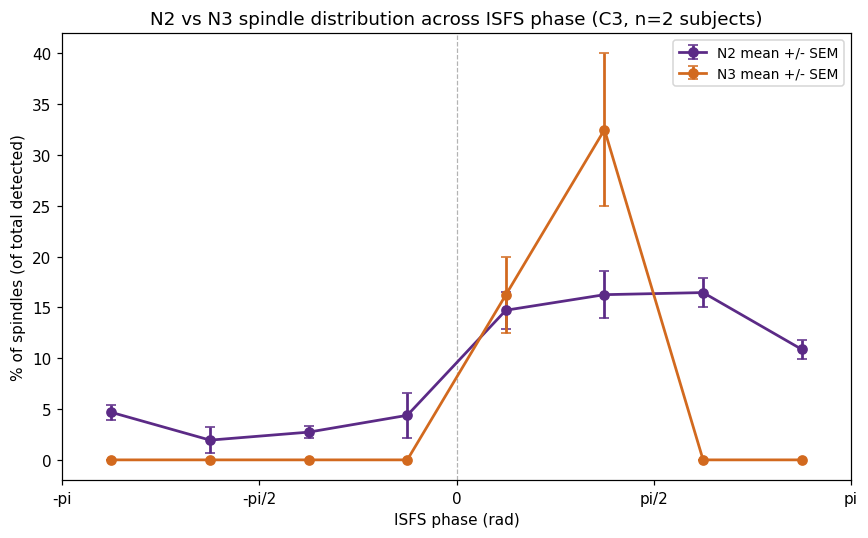

In [10]:
phase_mean = {state: stc.mean_sem(phase_rates[state]) for state in STATES}

fig, ax = plt.subplots(figsize=(8, 5))
for state in STATES:
    dark, light = COLORS[state]
    mean_r, sem_r = phase_mean[state]
    ax.errorbar(bin_centers, mean_r, yerr=sem_r, color=dark, marker="o", ms=6,
                capsize=3, lw=1.8, label=f"{state} mean +/- SEM")
ax.axvline(0, color="0.7", lw=0.8, ls="--")
ax.set(xlabel="ISFS phase (rad)", ylabel="% of spindles (of total detected)",
       xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
       xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
       title=f"N2 vs N3 spindle distribution across ISFS phase ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)")
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()

## 6. Peak-Frequency Distribution

### 6.1 Distribution Plot

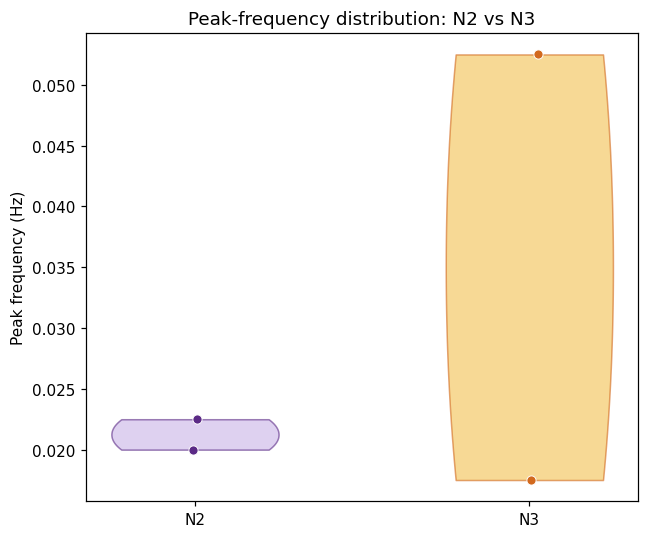

In [11]:
peak_freqs = {state: (n2_df if state == "N2" else n3_df)["peak_freq_hz"].to_numpy() for state in STATES}

fig, ax = plt.subplots(figsize=(6, 5))
positions = [1, 2]
parts = ax.violinplot([peak_freqs["N2"], peak_freqs["N3"]], positions=positions,
                       showmeans=False, showextrema=False)
for pc, state in zip(parts["bodies"], STATES):
    pc.set_facecolor(COLORS[state][1])
    pc.set_edgecolor(COLORS[state][0])
    pc.set_alpha(0.6)

rng = np.random.default_rng(0)
for pos, state in zip(positions, STATES):
    y = peak_freqs[state]
    x = rng.normal(pos, 0.04, size=y.size)
    ax.plot(x, y, "o", color=COLORS[state][0], ms=6, mec="white", mew=0.6, zorder=3)

ax.set(xticks=positions, xticklabels=STATES, ylabel="Peak frequency (Hz)",
       title="Peak-frequency distribution: N2 vs N3")
fig.tight_layout()

### 6.2 Paired Plot

,mean,sd,median,iqr
N2,0.02125,0.001768,0.02125,0.00125
N3,0.03500,0.024749,0.03500,0.01750


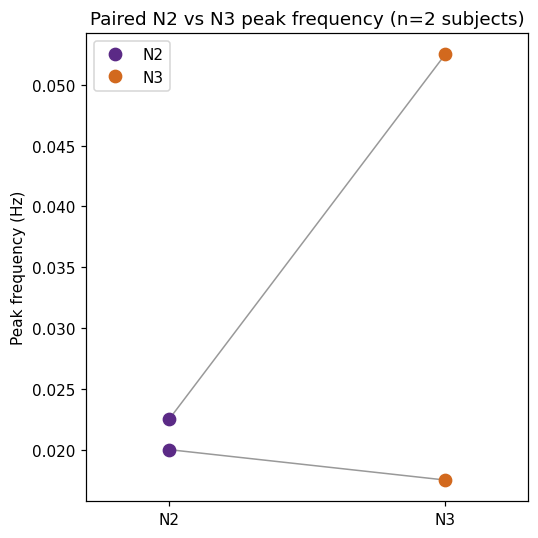

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
for n2_v, n3_v in zip(peak_freqs["N2"], peak_freqs["N3"]):
    ax.plot([1, 2], [n2_v, n3_v], color="0.6", lw=1.0, zorder=1)
ax.plot(np.ones_like(peak_freqs["N2"]), peak_freqs["N2"], "o", color=COLORS["N2"][0], ms=8,
        zorder=3, label="N2")
ax.plot(np.full_like(peak_freqs["N3"], 2), peak_freqs["N3"], "o", color=COLORS["N3"][0], ms=8,
        zorder=3, label="N3")
ax.set(xlim=(0.7, 2.3), xticks=[1, 2], xticklabels=STATES, ylabel="Peak frequency (Hz)",
       title=f"Paired N2 vs N3 peak frequency (n={len(SUBJECT_IDS)} subjects)")
ax.legend(frameon=True)
fig.tight_layout()

peak_freq_summary = pd.DataFrame({state: stc.describe(peak_freqs[state]) for state in STATES}).T
peak_freq_summary

## 7. Statistical Comparison

### 7.1 Peak Frequency

In [13]:
peak_ttest = stc.paired_ttest(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())
peak_dz = stc.paired_effect_size(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())

print(f"n={peak_ttest['n_pairs']} | N2 {peak_ttest['x_mean']:.4f}+/-{peak_ttest['x_sd']:.4f} Hz | "
      f"N3 {peak_ttest['y_mean']:.4f}+/-{peak_ttest['y_sd']:.4f} Hz | "
      f"mean diff={peak_ttest['mean_diff']:.4f} Hz | t={peak_ttest['t_stat']:.3f} | "
      f"p={peak_ttest['p_value']:.4g} | Cohen's dz={peak_dz:.3f}")

n=2 | N2 0.0212+/-0.0018 Hz | N3 0.0350+/-0.0247 Hz | mean diff=-0.0138 Hz | t=-0.846 | p=0.5529 | Cohen's dz=-0.598


### 7.2 Phase Bins

Paired t-test per ISFS phase bin (ordinary, on the bin-rate values -- not a circular test;
see the circular-preferred-phase supplement at the end of this section), BH-FDR corrected
across the 8 bins.

In [14]:
phase_bin_results = stc.compare_phase_bins(phase_rates["N2"], phase_rates["N3"], bin_centers)
phase_bin_results

,phase_bin,phase_center,N2_mean,N3_mean,mean_difference,n_pairs,t_stat,p_value,q_value,significant_FDR
0,1,-2.748894,4.674927,0.00,4.674927,2,6.664975,0.094810,0.252827,False
1,2,-1.963495,1.944029,0.00,1.944029,2,1.516667,0.371094,0.424108,False
2,3,-1.178097,2.730898,0.00,2.730898,2,4.705521,0.133309,0.266618,False
3,4,-0.392699,4.386527,0.00,4.386527,2,1.961783,0.300109,0.400145,False
4,5,0.392699,14.729759,16.25,-1.520241,2,-0.790365,0.574204,0.574204,False
5,6,1.178097,16.260770,32.50,-16.239230,2,-3.112320,0.197916,0.316665,False
6,7,1.963495,16.467279,0.00,16.467279,2,11.649874,0.054512,0.221093,False
7,8,2.748894,10.880866,0.00,10.880866,2,11.488722,0.055273,0.221093,False


### 7.3 Other ISFS Metrics

In [15]:
ISFS_METRICS = {
    "peak_freq_hz": "peak_frequency_hz",
    "peak_period_s": "peak_period_s",
    "bi_gaussian_amp": "amplitude",
    "bi_gaussian_sd_l": "sd_left",
    "bi_gaussian_sd_r": "sd_right",
    "bandwidth_hz": "bandwidth_hz",
    "auc": "auc",
    "chromatogram_peak_area": "chromatogram_peak_area",
}
isfs_metric_results = stc.compare_isfs_metrics(n2_df, n3_df, ISFS_METRICS)
isfs_metric_results

,Metric,N2 Mean,N2 SD,N3 Mean,N3 SD,Mean Difference,t,p,n_pairs,Cohen's dz,q
0,peak_frequency_hz,0.021250,0.001768,0.035000,0.024749,-0.013750,-0.846154,0.552929,2,-0.598321,0.899387
1,peak_period_s,47.222222,3.928371,38.095238,26.937401,9.126984,0.560976,0.674540,2,0.396670,0.899387
2,amplitude,11.392674,1.541530,3.514350,3.025269,7.878324,7.509162,0.084283,2,5.309779,0.337133
3,sd_left,0.025119,0.018994,0.027719,0.031511,-0.002599,-0.072777,0.953750,2,-0.051461,0.953750
4,sd_right,0.015536,0.005023,0.009801,0.003671,0.005734,0.932797,0.522126,2,0.659587,0.899387
5,bandwidth_hz,0.040655,0.024018,0.037520,0.035181,0.003135,0.074899,0.952407,2,0.052962,0.953750
6,auc,0.380462,0.180496,0.158354,0.202909,0.222107,0.819258,0.563041,2,0.579303,0.899387
7,chromatogram_peak_area,0.092082,0.019011,0.014925,0.010199,0.077157,12.381753,0.051305,2,8.755222,0.337133


#### Supplemental: circular preferred-phase comparison

`mean_phase` (each subject/state's own circular mean of in-cycle event angles, already
computed by `infraslow.pipeline.phase.compute_subject_phase_features`) is a circular
quantity -- a linear paired t-test on raw `(-pi, pi]` angles is not meaningful. This reports
the cohort's circular mean/resultant length per state instead, as a supplement to Section
7.2's ordinary (non-circular) phase-bin-rate paired tests, not a replacement for them.

`circular_mean_and_resultant` drops NaN angles independently per call, so if `mean_phase`
had NaNs in different subjects between N2 and N3, the two circular means below could
silently be computed over different subject subsets -- breaking this project's "every
paired comparison must report n_pairs and preserve subject pairing" constraint. Section
2's selection filter already guarantees every one of the `SUBJECT_IDS` has a finite
`mean_phase` in both states, so both counts below are expected to equal `len(SUBJECT_IDS)`;
we print them explicitly anyway as defense-in-depth, so a reader can see the n directly
rather than trusting it implicitly.

In [16]:
n2_valid_phase = n2_df["mean_phase"].notna().sum()
n3_valid_phase = n3_df["mean_phase"].notna().sum()
print(f"Valid (non-NaN) mean_phase: N2 {n2_valid_phase}/{len(n2_df)} subjects, "
      f"N3 {n3_valid_phase}/{len(n3_df)} subjects")

n2_circ = stc.circular_mean_and_resultant(n2_df["mean_phase"].to_numpy())
n3_circ = stc.circular_mean_and_resultant(n3_df["mean_phase"].to_numpy())
print(f"N2 circular mean phase = {n2_circ[0]:.3f} rad, resultant length = {n2_circ[1]:.3f}")
print(f"N3 circular mean phase = {n3_circ[0]:.3f} rad, resultant length = {n3_circ[1]:.3f}")

Valid (non-NaN) mean_phase: N2 2/2 subjects, N3 2/2 subjects
N2 circular mean phase = 1.487 rad, resultant length = 0.983
N3 circular mean phase = 0.923 rad, resultant length = 1.000


## 8. Summary

In [17]:
n_sig_bins = int(phase_bin_results["significant_FDR"].sum())
n_sig_metrics = int((isfs_metric_results["q"] < 0.05).sum())

print("Summary")
print("=======")
print(f"Subjects: {len(SUBJECT_IDS)} (channel {CHANNEL}), paired N2/N3 usable data")
print(f"Peak frequency: N2 {peak_ttest['x_mean']:.4f} Hz vs N3 {peak_ttest['y_mean']:.4f} Hz, "
      f"t({peak_ttest['n_pairs'] - 1})={peak_ttest['t_stat']:.3f}, p={peak_ttest['p_value']:.4g}, "
      f"Cohen's dz={peak_dz:.3f}")
print(f"Phase bins significant after FDR (q<0.05): {n_sig_bins}/8")
print(f"ISFS metrics significant after FDR (q<0.05): {n_sig_metrics}/{len(isfs_metric_results)}")
print(f"N2 circular mean phase: {n2_circ[0]:.3f} rad (resultant {n2_circ[1]:.3f})")
print(f"N3 circular mean phase: {n3_circ[0]:.3f} rad (resultant {n3_circ[1]:.3f})")

Summary
Subjects: 2 (channel C3), paired N2/N3 usable data
Peak frequency: N2 0.0212 Hz vs N3 0.0350 Hz, t(1)=-0.846, p=0.5529, Cohen's dz=-0.598
Phase bins significant after FDR (q<0.05): 0/8
ISFS metrics significant after FDR (q<0.05): 0/8
N2 circular mean phase: 1.487 rad (resultant 0.983)
N3 circular mean phase: 0.923 rad (resultant 1.000)
